# Installs and Imports

In [ ]:
%%capture
!pip install -U datasets

In [ ]:
from datasets import load_dataset
import json
import shutil
import random
from copy import deepcopy
from pathlib import Path
import glob
from multiprocessing import Pool as ThreadPool
from functools import partial
import os
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt

# Set drive connection and dataset crawl from huggingface

In [ ]:
drive.mount("/content/drive", force_remount=True)

In [ ]:
huggingface_dataset_name = "mwritescode/slither-audited-smart-contracts"
dataset = load_dataset(huggingface_dataset_name, 'all-plain-text', split="train")
dataset

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.12k [00:00<?, ?B/s]

slither-audited-smart-contracts.py:   0%|          | 0.00/8.00k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/19.9k [00:00<?, ?B/s]

The repository for mwritescode/slither-audited-smart-contracts contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/mwritescode/slither-audited-smart-contracts.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


...

data/label_mappings.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

data/big-splits.csv:   0%|          | 0.00/4.97M [00:00<?, ?B/s]

data/small-splits.csv:   0%|          | 0.00/659k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120608 [00:00<?, ? examples/s]

Dataset({
    features: ['address', 'source_code', 'bytecode', 'slither'],
    num_rows: 120608
})

In [ ]:
df = dataset.to_pandas()
df

,address,source_code,bytecode,slither
0,0x006699d34AA3013605d468d2755A2Fe59A16B12B,pragma solidity 0.5.4;\n\ninterface IERC20 {\n...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {""..."
1,0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,pragma solidity 0.6.10;\npragma experimental A...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {""..."
2,0x010c5322d78c88ca18282b0a072a8913648b3038,pragma solidity 0.6.5;\npragma experimental AB...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {}}"
3,0x0114622386c1a00686e594c70682d7aa0f8afa29,pragma solidity 0.6.6;\n\nlibrary Address {\n\...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {}}"
4,0x01A6F6Ac4F5b2564e8C52BA687E7019D0E81E7e8,pragma solidity 0.6.8;\npragma experimental AB...,0x6080604052600436106101665760003560e01c80637d...,"{""success"": true, ""error"": null, ""results"": {""..."
...,...,...,...,...
120603,0x80d19b2bf1743371855732971cec24fe9dcd1417,/**\n *Submitted for verification at Etherscan...,0x7380d19b2bf1743371855732971cec24fe9dcd141730...,"{""success"": true, ""error"": null, ""results"": {}}"
120604,0x810b54cdb3d8c97d857b500cdfdb5715e1d27837,contract ERC20Basic {\n uint256 public totalS...,0x6060604052600436106100c5576000357c0100000000...,"{""success"": true, ""error"": null, ""results"": {}}"
120605,0x8142871ce8e9b69af8b50369fde8f9959d699fa6,contract Bodies2 {\n\nstring public constant b...,0x608060405234801561001057600080fd5b5060043610...,"{""success"": true, ""error"": null, ""results"": {}}"
120606,0x8154094af8dc315b31c6ec746260003ee828fd93,contract LifeSet_005 {\n \n// part.I_fixe.....,0x6080604052600436106100da5763ffffffff7c010000...,"{""success"": true, ""error"": null, ""results"": {}}"


# Source code with vulnerability extraction

In [ ]:
def remove_comments(solidity_code):
    # Regex patterns to match single-line and multi-line comments
    single_line_comment_pattern = r"//.*?(?=\n|$)"
    multi_line_comment_pattern = r"/\*.*?\*/"

    # Remove single-line comments
    code_without_single_line_comments = re.sub(single_line_comment_pattern, '', solidity_code, flags=re.DOTALL)

    # Remove multi-line comments
    cleaned_code = re.sub(multi_line_comment_pattern, '', code_without_single_line_comments, flags=re.DOTALL)

    return cleaned_code.strip()

true = True
null = None

groups = {'re_entrancy': ['reentrancy-benign', 'reentrancy-eth', 'reentrancyunlimited-gas', 'reentrancy-no-eth'],
          'timestamp_dependency': ['timestamp'],
          'unhandled_exceptions': ['unchecked-send', 'unchecked-lowlevel']}

reentrancy_group = []
timestamp_group = []
unchecked_group = []
tx_origin_group = []

cnt = 0

for k in range(len(groups)):
    for i in range(len(df)):
        tlist = df.iloc[i]['slither']
        tmp_dict = eval(tlist)
        if tmp_dict['results'] != {}:
            sol_er_list = tmp_dict['results']['detectors']
            sol_er_list = [er['check'] for er in sol_er_list]
            match_list = list(set(sol_er_list) & set(groups[k]))
            sol_ner_list = []

            for ng in range(len(groups)):
                if ng != k:
                    group = groups[ng]
                    sol_ner_list += group

            unmatch_list = list(set(sol_ner_list) & set(groups[k]))
            if len(match_list) > 0 and len(unmatch_list) == 0:
                if k == 0:
                    reentrancy_group.append((df.iloc[i]['address'], df.iloc[i]['source_code'], sol_er_list))
                elif k == 1:
                    timestamp_group.append((df.iloc[i]['address'], df.iloc[i]['source_code'], sol_er_list))
                elif k == 2:
                    unchecked_group.append((df.iloc[i]['address'], df.iloc[i]['source_code'], sol_er_list))


print("reentrancy_group:".title(), len(reentrancy_group))
print("timestamp_group:".title(), len(timestamp_group))
print("unchecked_group:".title(), len(unchecked_group))

In [ ]:
pd.set_option('max_colwidth', 400)
tmp_df = pd.DataFrame(reentrancy_group, columns=['address', 'source_code', 'errors'])
tmp_df

In [ ]:
# Reading folders first because folders for now might be too large, colab python require to read it again if the reading time it's out of waiting limit

dataSources = ['/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/unhandled_exceptions',
               '/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/benign',
               '/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/re_entrancy',
               '/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/timestamp_dependency',
               '/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/tx_origin']

i = 0
while i < len(dataSources):
  try:
    tmp = os.listdir(dataSources[i])
    print("Finish reading data dir: [", dataSources[i], "] with number of files:", len(tmp))
    i += 1
  except Exception as e:
    print(e)
    pass

In [ ]:
# Start writting new files in dataset

def write_file(sol_info, dest):
  """
    This function create in order to help changing collected
    data from csv such as: Src Address, Src Code to File
    - sol_info (tuple): (sol_name, sol_code)
    - dest (str): Destination to the .sol saved file
  """
  try:
    sol_name, sol_code = sol_info
    with open(f'{dest}/{sol_name}.sol', 'w') as f:
      f.write(sol_code)
    print('Finish writting SOL file:', f'{dest}/{sol_name}.sol')
  except Exception as e:
    print("Error writting file:", str(e))


for ftype in ["unhandled_exceptions", "tx_origin"]:
  # Example usage
  sol_list = unchecked_group if ftype == "unhandled_exceptions" else tx_origin_group
  solFileDst = f'/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/{ftype}'

  pool = ThreadPool(8)
  pool.map(partial(write_file, dest=solFileDst), sol_list)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
   /content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/unhandled_exceptions/0x1ba3f2ea2ffc809a7b871ac8781906065aa04bfb.sol/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/unhandled_exceptions/0x2d628b2bf4886d0b8b8ce902d88f9811da220ea2.sol/content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/unhandled_exceptions/0x18CfB667F10c004f9534eA3C928b864d14c8fc11.solFinish writting SOL file:


 /content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/unhandled_exceptions/0x11eb0ef0bb540de51e667c14b6677942114ad23f.sol
Finish writting SOL file: /content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/unhandled_exceptions/0x36f36d57a75235ff333f4bb981d301639e268c5b.sol
Finish writting SOL file: /content/drive/MyDrive/ScamSolidityCodeDetection/SolCodeDataset/unhandled_exceptions/0x060e73d693bff0b39239a1dc39274b0ca676a701.sol
Finish writting SOL file: /content/drive/MyDrive/ScamSolidityCodeDetec

# EDA

In [ ]:
# def remove_comments(solidity_code):
#     # Regex patterns to match single-line and multi-line comments
#     single_line_comment_pattern = r"//.*?(?=\n|$)"
#     multi_line_comment_pattern = r"/\*.*?\*/"

#     # Remove single-line comments
#     code_without_single_line_comments = re.sub(single_line_comment_pattern, '', solidity_code, flags=re.DOTALL)

#     # Remove multi-line comments
#     cleaned_code = re.sub(multi_line_comment_pattern, '', code_without_single_line_comments, flags=re.DOTALL)

#     return cleaned_code.strip()

# true = True
# null = None

# groups = [['unchecked-send', 'unchecked-lowlevel']]

# unchecked_group = {'unchecked-send': [],
#                    'unchecked-lowlevel': []}

# cnt = 0

# for k in range(len(groups)):
#     for i in range(len(df)):
#         tlist = df.iloc[i]['slither']
#         tmp_dict = eval(tlist)
#         if tmp_dict['results'] != {}:
#             sol_er_list = tmp_dict['results']['detectors']
#             sol_er_list = [er['check'].lower().strip() for er in sol_er_list]
#             # match_list = list(set(sol_er_list) & set(groups[k]))
#             for er in sol_er_list:
#                 if er in groups[k]:
#                     unchecked_group[er].append((df.iloc[i]['address'], remove_comments(df.iloc[i]['source_code'])))
#                     # break

#             # if len(match_list) > 0:
#             #     if k == 0:
#             #         unchecked_group.append((df.iloc[i]['address'], remove_comments(df.iloc[i]['source_code'])))


# print("unchecked_group:".title(), len(unchecked_group['unchecked-send']), len(unchecked_group['unchecked-lowlevel']))

Unchecked_Group: 260 1760


In [ ]:
with open("result.json", "r") as f:
    data = json.load(f)

display(data)

for uncheck in unchecked_group.keys():
    data[f"unhandled_exceptions ({uncheck})"] = len(unchecked_group[uncheck])

display(data)

{'re_entrancy (reentrancy-benign)': 1726,
 're_entrancy (reentrancy-eth)': 1335,
 're_entrancy (reentrancy-no-eth)': 5331,
 're_entrancy (state change after external call)': 3129,
 'timestamp_dependency (timestamp)': 1940,
 'timestamp_dependency (dependence on predictable environment variable)': 454,
 'timestamp_dependency (solidity_exact_time)': 56,
 'unhandled_exceptions (solidity_unchecked_call)': 1707,
 'unhandled_exceptions (unchecked call return value)': 422}

{'re_entrancy (reentrancy-benign)': 1726,
 're_entrancy (reentrancy-eth)': 1335,
 're_entrancy (reentrancy-no-eth)': 5331,
 're_entrancy (state change after external call)': 3129,
 'timestamp_dependency (timestamp)': 1940,
 'timestamp_dependency (dependence on predictable environment variable)': 454,
 'timestamp_dependency (solidity_exact_time)': 56,
 'unhandled_exceptions (solidity_unchecked_call)': 1707,
 'unhandled_exceptions (unchecked call return value)': 422,
 'unhandled_exceptions (unchecked-send)': 260,
 'unhandled_exceptions (unchecked-lowlevel)': 1760}

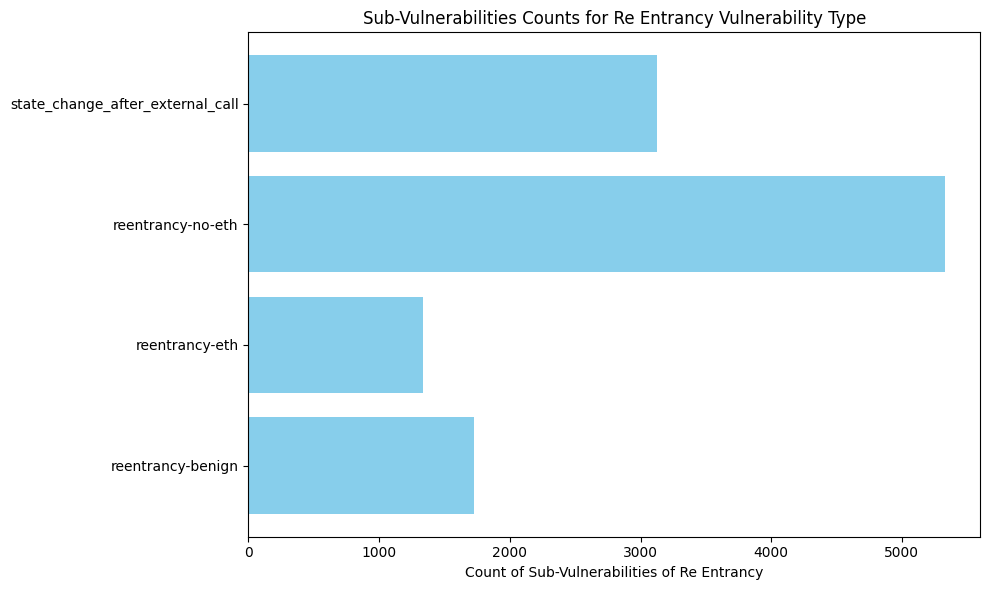

In [ ]:
# Data for the sub-vulnerabilities
vulnerabilities = {
    're_entrancy': {
        'reentrancy-benign': 1726,
        'reentrancy-eth': 1335,
        'reentrancy-no-eth': 5331,
        'state_change_after_external_call': 3129
    },
    'timestamp_dependency': {
        'timestamp': 1940,
        'dependence_on_predictable_env_var': 454,
        'solidity_exact_time': 56
    },
    'unhandled_exceptions': {
        'solidity_unchecked_call': 1707,
        'unchecked_call_return_value': 422,
        'unchecked_send': 260,
        'unchecked_lowlevel': 1760
    }
}

# # Prepare data for plotting
# categories = list(vulnerabilities.keys())
# sub_vulnerabilities = []
# counts = []

# # Loop through the dictionary and prepare the data for plotting
# for category in categories:
#     for sub_vuln, count in vulnerabilities[category].items():
#         sub_vulnerabilities.append(f'{category} ({sub_vuln})')
#         counts.append(count)

vul_type = "re_entrancy"

# Plot the data
plt.figure(figsize=(10, 6)

           )
plt.barh(list(vulnerabilities[vul_type].keys()), list(vulnerabilities[vul_type].values()), color='skyblue')
plt.xlabel(f'Count of Sub-Vulnerabilities of {vul_type.title().replace("_", " ")}')
plt.title(f'Sub-Vulnerabilities Counts for {vul_type.title().replace("_", " ")} Vulnerability Type')
plt.tight_layout()
plt.show()

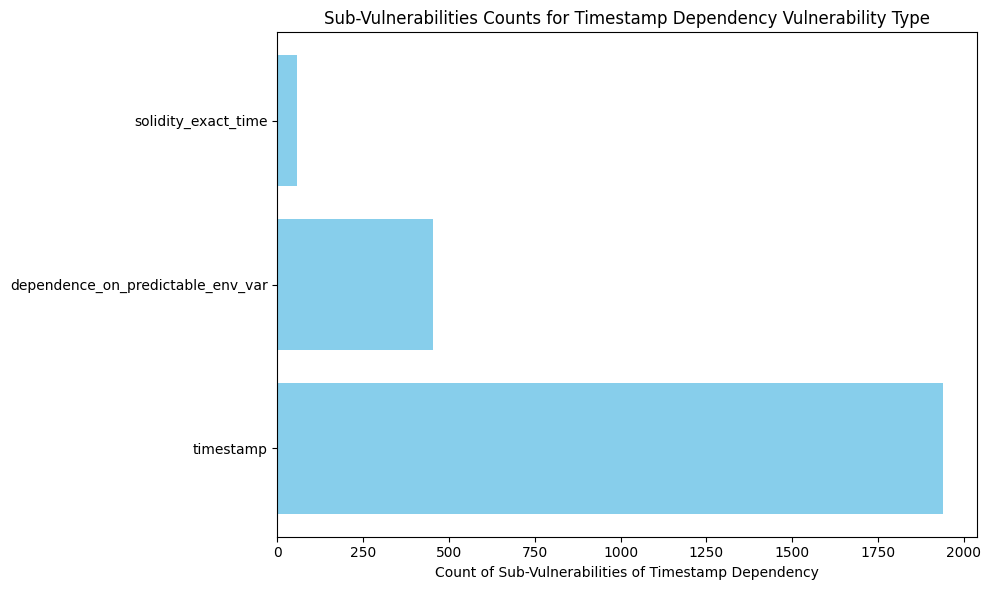

In [ ]:
vul_type = "timestamp_dependency"

# Plot the data
plt.figure(figsize=(10, 6)

           )
plt.barh(list(vulnerabilities[vul_type].keys()), list(vulnerabilities[vul_type].values()), color='skyblue')
plt.xlabel(f'Count of Sub-Vulnerabilities of {vul_type.title().replace("_", " ")}')
plt.title(f'Sub-Vulnerabilities Counts for {vul_type.title().replace("_", " ")} Vulnerability Type')
plt.tight_layout()
plt.show()

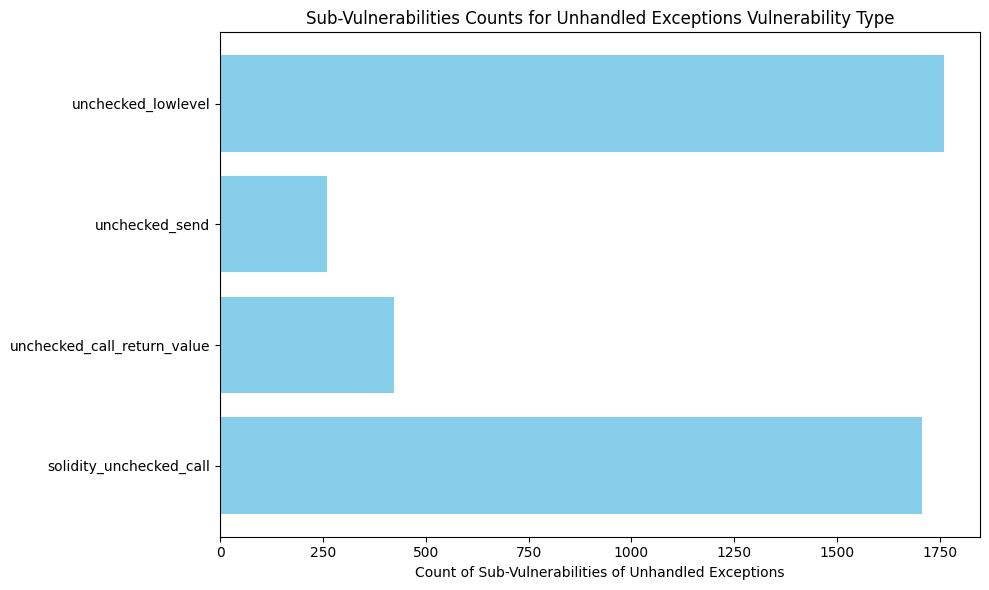

In [ ]:
vul_type = "unhandled_exceptions"

# Plot the data
plt.figure(figsize=(10, 6)

           )
plt.barh(list(vulnerabilities[vul_type].keys()), list(vulnerabilities[vul_type].values()), color='skyblue')
plt.xlabel(f'Count of Sub-Vulnerabilities of {vul_type.title().replace("_", " ")}')
plt.title(f'Sub-Vulnerabilities Counts for {vul_type.title().replace("_", " ")} Vulnerability Type')
plt.tight_layout()
plt.show()

In [ ]:
print(vulnerabilities[vul_type].values())

dict_values([1726, 1335, 5331, 3129])
